<a href="https://colab.research.google.com/github/abyanmaheswara/Prediksi-Kelanggengan-Hubungan-Pernikahanan/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil di-import!")


Library berhasil di-import!


In [33]:
from google.colab import files
uploaded = files.upload()  # Upload file marriage_longevity_master.csv

df = pd.read_csv("marriage_longevity_master.csv")
print(f"Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()


Saving marriage_longevity_master.csv to marriage_longevity_master (2).csv
Dataset: 45000 baris, 24 kolom


,marriage_id,marriage_number,age_at_marriage,age_gap_years,education_level,household_income_usd,financial_stress,both_employed,cohabited_before,premarital_counseling,...,contempt,defensiveness,stonewalling,repair_attempt_success,positive_negative_ratio,conflict_frequency_weekly,shared_activities_weekly,years_married,years_to_divorce,divorced
0,MAR000000,1,36,6,less_than_hs,68600.0,5.9,1,1,0,...,7.7,5.8,8.1,4.1,2.22,3.0,4.0,22.0,NaN,0
1,MAR000001,2,59,1,some_college,328800.0,0.0,1,1,0,...,1.7,6.8,3.0,5.1,11.99,1.0,1.0,15.5,NaN,0
2,MAR000002,2,44,1,high_school,139900.0,6.1,0,0,1,...,6.5,4.2,4.8,5.7,2.27,4.0,2.0,7.2,NaN,0
3,MAR000003,1,25,2,bachelors,97600.0,5.9,1,1,1,...,0.0,4.1,0.9,8.7,6.24,0.0,4.0,13.5,NaN,0
4,MAR000004,2,29,3,graduate,98200.0,4.0,0,0,1,...,4.4,4.6,9.6,8.9,2.59,4.0,5.0,7.5,7.5,1


In [34]:
print("="*50)
print("INFO DATASET")
print("="*50)
print(f"\nShape: {df.shape}")
print(f"\nTipe Data:")
print(df.dtypes)
print(f"\nStatistik Deskriptif:")
df.describe()


INFO DATASET

Shape: (45000, 24)

Tipe Data:
marriage_id                   object
marriage_number                int64
age_at_marriage                int64
age_gap_years                  int64
education_level               object
household_income_usd         float64
financial_stress             float64
both_employed                  int64
cohabited_before               int64
premarital_counseling          int64
child_before_marriage          int64
n_children                     int64
religious_attendance          object
criticism                    float64
contempt                     float64
defensiveness                float64
stonewalling                 float64
repair_attempt_success       float64
positive_negative_ratio      float64
conflict_frequency_weekly    float64
shared_activities_weekly     float64
years_married                float64
years_to_divorce             float64
divorced                       int64
dtype: object

Statistik Deskriptif:


,marriage_number,age_at_marriage,age_gap_years,household_income_usd,financial_stress,both_employed,cohabited_before,premarital_counseling,child_before_marriage,n_children,...,contempt,defensiveness,stonewalling,repair_attempt_success,positive_negative_ratio,conflict_frequency_weekly,shared_activities_weekly,years_married,years_to_divorce,divorced
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,...,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,20708.000000,45000.000000
mean,1.302244,30.168644,2.868156,118024.922222,5.186407,0.658667,0.618178,0.243822,0.189644,1.404733,...,3.256393,4.760267,3.801571,5.628598,4.011752,2.378267,3.035089,10.699487,7.721021,0.460178
std,0.560842,7.588164,2.205134,83738.454555,2.357498,0.474162,0.485839,0.429391,0.392024,1.183376,...,2.181556,2.154957,2.169450,2.284411,2.852853,1.656582,1.920517,7.820057,4.848361,0.498417
min,1.000000,16.000000,0.000000,9000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.500000,0.500000,0.000000
25%,1.000000,25.000000,1.000000,61800.000000,3.600000,0.000000,0.000000,0.000000,0.000000,1.000000,...,1.600000,3.300000,2.200000,4.000000,2.080000,1.000000,2.000000,5.100000,4.200000,0.000000
50%,1.000000,29.000000,2.000000,95700.000000,5.200000,1.000000,1.000000,0.000000,0.000000,1.000000,...,3.200000,4.800000,3.800000,5.700000,3.260000,2.000000,3.000000,8.700000,6.700000,0.000000
75%,2.000000,34.000000,4.000000,148400.000000,6.800000,1.000000,1.000000,0.000000,0.000000,2.000000,...,4.800000,6.200000,5.300000,7.300000,5.060000,3.000000,4.000000,14.000000,10.200000,1.000000
max,3.000000,68.000000,16.000000,600000.000000,10.000000,1.000000,1.000000,1.000000,1.000000,6.000000,...,10.000000,10.000000,10.000000,10.000000,20.000000,12.000000,15.000000,55.000000,45.000000,1.000000


In [35]:
print("="*50)
print("MISSING VALUES")
print("="*50)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Kolom': missing.index,
    'Jumlah Missing': missing.values,
    'Persentase (%)': missing_pct.values
})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("Tidak ada missing values!")

print(f"\nTotal missing values: {df.isnull().sum().sum()}")


MISSING VALUES
           Kolom  Jumlah Missing  Persentase (%)
years_to_divorce           24292           53.98

Total missing values: 24292


In [36]:
print("="*50)
print("DATA DUPLIKAT")
print("="*50)

duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplikat}")
print(f"Persentase duplikat: {duplikat/len(df)*100:.2f}%")


DATA DUPLIKAT
Jumlah baris duplikat: 0
Persentase duplikat: 0.00%


DISTRIBUSI TARGET (divorced)
Langgeng (0): 24292 (54.0%)
Cerai   (1): 20708 (46.0%)


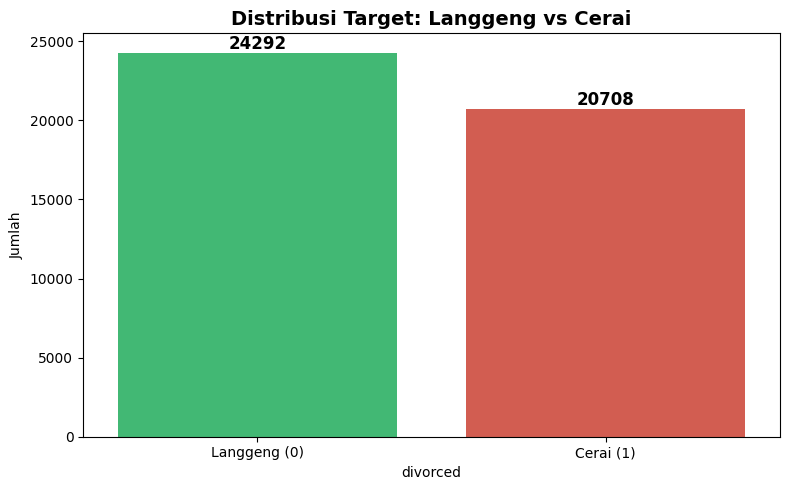

In [37]:
print("="*50)
print("DISTRIBUSI TARGET (divorced)")
print("="*50)

count_0 = (df['divorced'] == 0).sum()
count_1 = (df['divorced'] == 1).sum()

print(f"Langgeng (0): {count_0} ({count_0/len(df)*100:.1f}%)")
print(f"Cerai   (1): {count_1} ({count_1/len(df)*100:.1f}%)")

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='divorced', data=df, palette=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['Langgeng (0)', 'Cerai (1)'])
plt.title('Distribusi Target: Langgeng vs Cerai', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


DETEKSI OUTLIER (Metode IQR)
                    Kolom  Outlier  Persentase (%)
    premarital_counseling    10972           24.38
    child_before_marriage     8534           18.96
               n_children     2405            5.34
     household_income_usd     2290            5.09
  positive_negative_ratio     2290            5.09
            years_married     1923            4.27
          age_at_marriage     1288            2.86
 shared_activities_weekly      994            2.21
            age_gap_years      836            1.86
conflict_frequency_weekly      769            1.71
         years_to_divorce      585            1.30
                 contempt      158            0.35
             stonewalling      146            0.32
          marriage_number        0            0.00
            both_employed        0            0.00
         cohabited_before        0            0.00
                criticism        0            0.00
         financial_stress        0            0.00
  

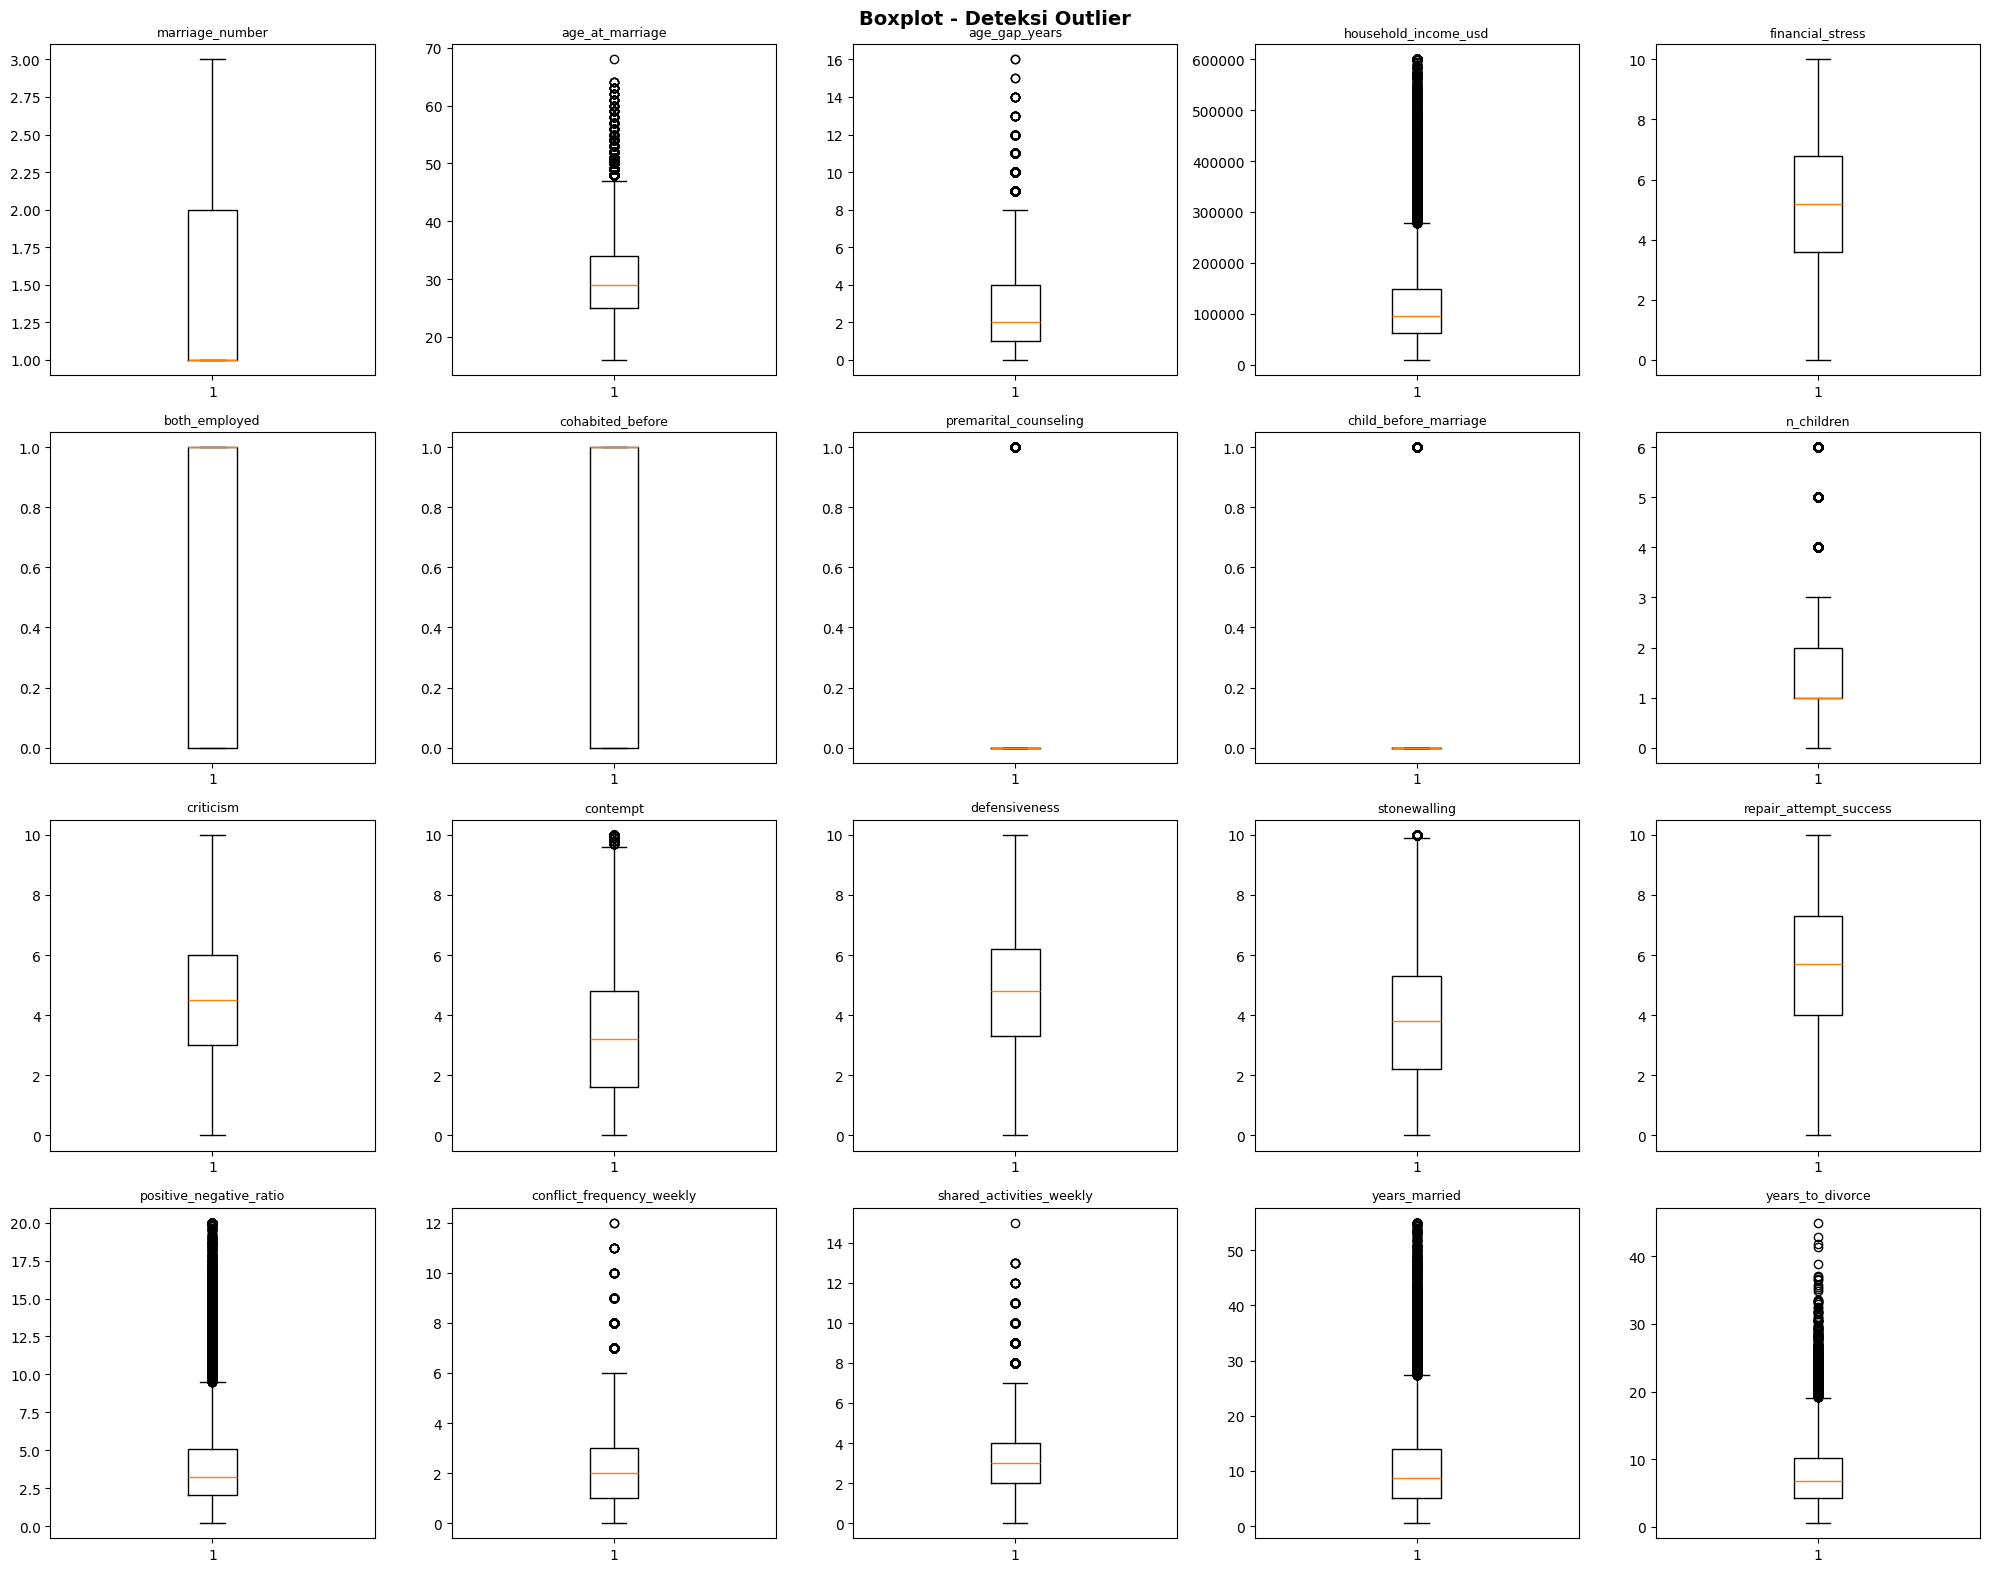

In [38]:
print("="*50)
print("DETEKSI OUTLIER (Metode IQR)")
print("="*50)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'divorced']

outlier_info = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outlier / len(df) * 100
    outlier_info.append({'Kolom': col, 'Outlier': n_outlier, 'Persentase (%)': round(pct, 2)})

outlier_df = pd.DataFrame(outlier_info).sort_values('Outlier', ascending=False)
print(outlier_df.to_string(index=False))

# Boxplot
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:20]):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot - Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


KORELASI ANTAR FITUR


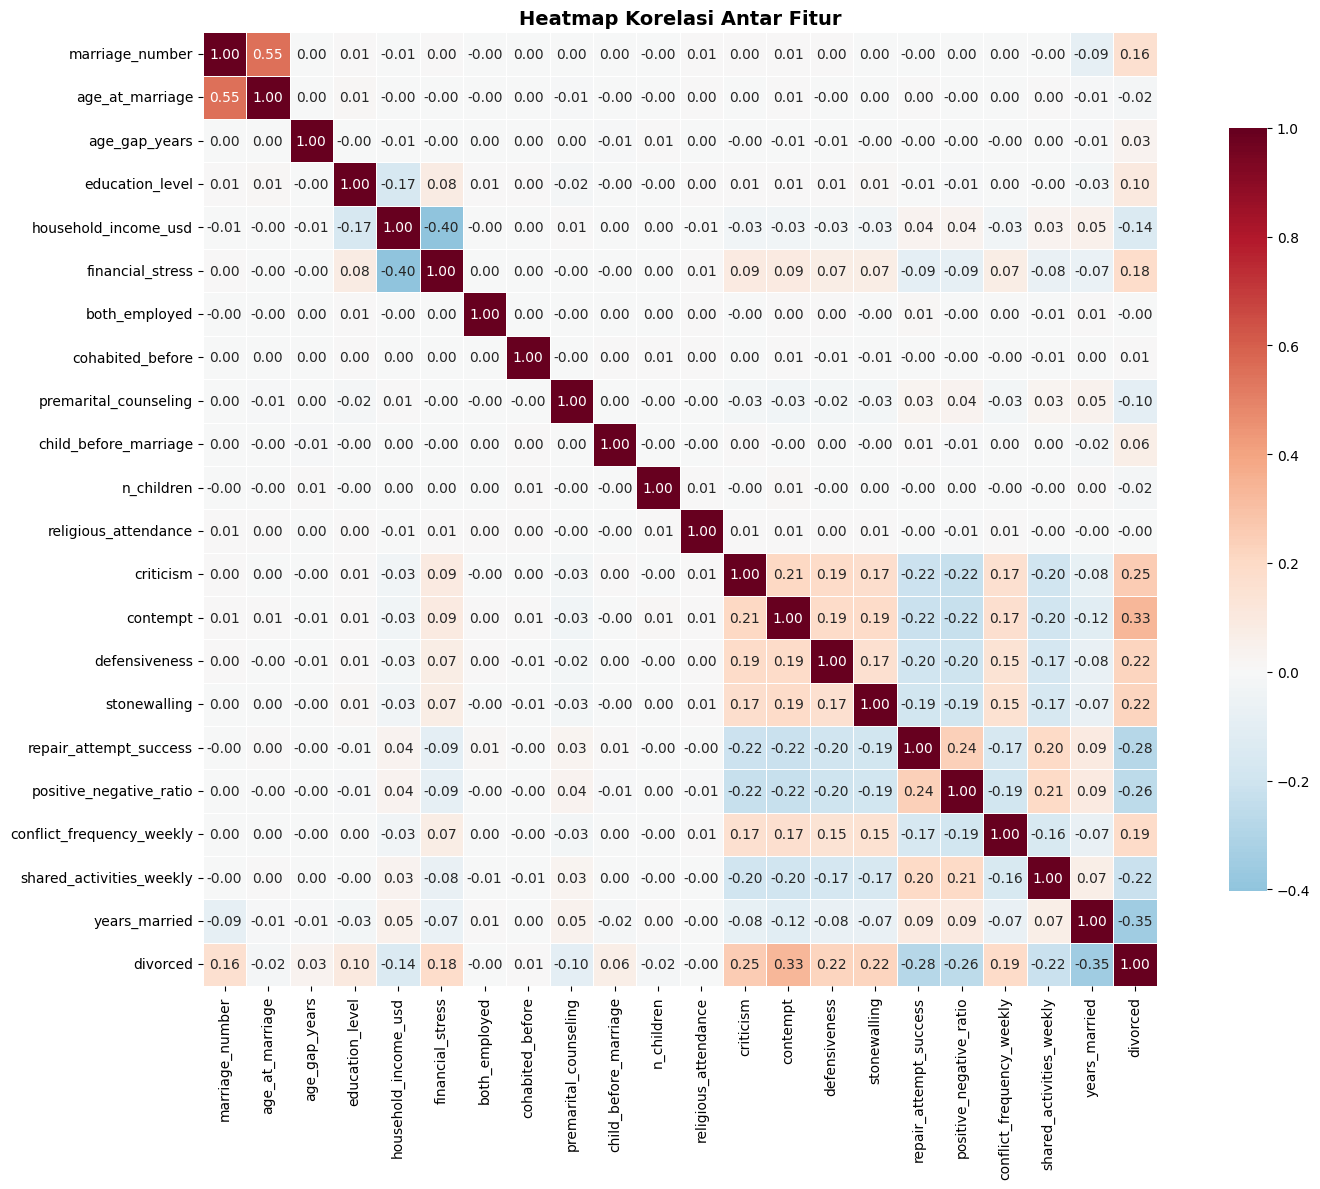

In [39]:
print("="*50)
print("KORELASI ANTAR FITUR")
print("="*50)

df_corr = df.drop(columns=['marriage_id', 'years_to_divorce'], errors='ignore')
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

corr_matrix = df_corr.corr()

# Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


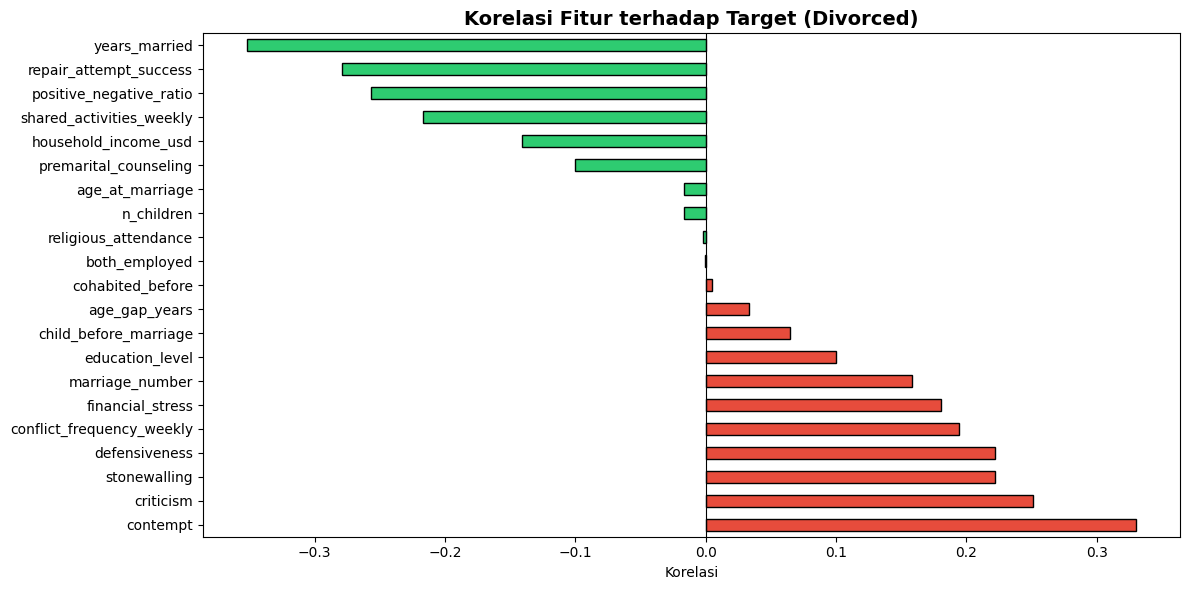


3 Fitur dengan korelasi POSITIF terkuat (meningkatkan risiko cerai):
  contempt: 0.3298
  criticism: 0.2513
  stonewalling: 0.2222

3 Fitur dengan korelasi NEGATIF terkuat (menurunkan risiko cerai):
  positive_negative_ratio: -0.2571
  repair_attempt_success: -0.2787
  years_married: -0.3517


In [40]:
corr_target = corr_matrix['divorced'].drop('divorced').sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in corr_target.values]
corr_target.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Korelasi Fitur terhadap Target (Divorced)', fontsize=14, fontweight='bold')
plt.xlabel('Korelasi')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n3 Fitur dengan korelasi POSITIF terkuat (meningkatkan risiko cerai):")
for feat, val in corr_target.head(3).items():
    print(f"  {feat}: {val:.4f}")

print("\n3 Fitur dengan korelasi NEGATIF terkuat (menurunkan risiko cerai):")
for feat, val in corr_target.tail(3).items():
    print(f"  {feat}: {val:.4f}")
